# NeSPReSO from scratch — all main models (incl. cube-native)

Full pipeline with **`USE_TRAINED_MODEL = False`**: rebuild the GoM Zarr cube, rebuild every
train-ready cache with `force=True`, train every model fresh, then evaluate all of them on the
**chronological 70/15/15 test split** (n=623) in physical space.

| Row | Pipeline | Inputs → targets |
|-----|----------|------------------|
| Climatology | baseline | harmonic climatology (train-fit) |
| Clim + SLA GEM | baseline | + DUACS SLA per-depth regression |
| Point (raw PCs) | v2 pickle (`argo_v2`) | 9-D scalars → raw PCs (`PatchConvMLP`) — "golden" lineage |
| ANOM-point | v2 pickle, anomaly targets | 9-D scalars → anomaly PCs |
| ANOM-L4-patch | per-profile HDF5 (`argo_l4`) | 5×5×7-day L4 patches → anomaly PCs (`PatchMaskConvMLP`) |
| Point-cube | **Zarr cube** (`argo_cube`) | 9-D cube-sampled features → raw PCs |
| Cube residual | Zarr cube, 41-D features | point-anchored residual (`PointAnchoredResidual`, ReZero gate) |

**Split discipline (HANDOFF_cube-native §10):** every number below is chronological-test.
Reference points: golden chrono T=0.514/S=0.083, point_cube T=0.577/S=0.089, clim T=1.657/S=0.216.

**Order matters:** cube caches take their PCA basis from the freshly trained point model
(`io.pca_ckpt`), and the residual model warm-starts from the freshly trained point_cube
(`arch.args.warmstart_ckpt`) — both are wired at runtime, not from the JSON defaults.

**Workflow:** setup → stats contract → config matrix → cube rebuild+validate → legacy caches →
train (point, anom-point, anom-patch) → cube caches + train point_cube → S0 anchoring check +
train residual → rows → summary → depth structure → scatter/residuals → examples → maps → export.

## Section 0 — Setup

In [1]:
from __future__ import annotations

import copy
import json
import os
import pickle
import shutil
import subprocess
import sys
import time
import traceback
from collections import OrderedDict
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

%matplotlib inline

NOTEBOOK_DIR = Path.cwd().resolve()
TEMPLATE_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "NeSPReSO2_onTemplate"
os.chdir(TEMPLATE_ROOT)  # configs use cwd-relative paths (matches CLI train.py runs)
sys.path.insert(0, str(TEMPLATE_ROOT))
sys.path.insert(0, str(TEMPLATE_ROOT / "notebooks"))

# False => rebuild caches (force) + retrain everything; override with env USE_TRAINED_MODEL=1
USE_TRAINED_MODEL = os.environ.get("USE_TRAINED_MODEL", "0") == "1"
REBUILD_CUBE = not USE_TRAINED_MODEL  # cube rebuilt only if data_revision on disk is stale
FORCE_CACHES = not USE_TRAINED_MODEL
EVAL_SPLIT = "test"

STAMP = datetime.now().strftime("%m%d_%H%M%S")
OUT_DIR = TEMPLATE_ROOT / "notebooks" / "scratch_outputs"
OUT_DIR.mkdir(exist_ok=True)
MANIFEST_PATH = OUT_DIR / "scratch_manifest.json"
manifest = json.loads(MANIFEST_PATH.read_text()) if MANIFEST_PATH.exists() else {}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PYEXE = sys.executable

from parse_config import ConfigParser, validate_config
from train import main as train_main
import model.model as module_arch
from nb_checkpoints import checkpoint_epoch
from nb_metrics import (
    avg_common_rmse,
    assert_matches_eval_run,
    plot_depth_rmse_overlay,
    profile_metrics_from_inference,
    statistics_markdown,
)
import nb_anom

print(f"Device: {DEVICE} | python: {PYEXE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Template: {TEMPLATE_ROOT}")
print(f"Run stamp: {STAMP} | USE_TRAINED_MODEL={USE_TRAINED_MODEL}")

Device: cuda | python: /conda/jmiranda/miniconda/envs/nespreso/bin/python
GPU: NVIDIA A100-SXM4-80GB
Template: /unity/g2/jmiranda/SubsurfaceFields/Data/ISAS20_ARGO/ISAS20_project/NeSPReSO2_onTemplate
Run stamp: 0706_002515 | USE_TRAINED_MODEL=True


## Section 1 — Statistics contract

All physical-space RMSE; anomaly models get the climatology add-back; scalar RMSE on the
common 0–1800 m @ 10 m grid. Raw-PC and anomaly-PC rows are directly comparable this way.

In [2]:
print(statistics_markdown())

| Statistic | Units | Definition |
|---|---|---|
| `raw_profile_rmse_common` | °C or PSU | sqrt(nanmean((pred−true)²)) over all samples in the split and all depth levels on the common grid 0.0–1800.0 m (step 10.0 m). Truth = cache['profiles'] (raw, not PCA-reconstructed). Pred = inverse_PCA(model PCs) or frozen-AE decode (decoder mode) interpolated to the common grid. |
| `raw_profile_rmse_native` | °C or PSU | Same as raw_profile_rmse_common but on each cache's native PRES grid (no interpolation). Matches eval_run.py raw_profile_rmse when the native grid spans 0–1800 m. |
| `depth_rmse` | °C or PSU | Per-depth sqrt(nanmean over samples of (pred−true)²) on the common grid within 0.0–1800.0 m. |
| `depth_bias` | °C or PSU | Per-depth nanmean(pred−true) on the common grid within 0.0–1800.0 m. |
| `bin_map_rmse` | °C or PSU | Per 1° GoM bin: sqrt(nanmean((pred−true)²)) over profiles and common-grid depths in that bin (fixed -99..-81°W, 18..30°N extent). |
| `profile_recon_rmse` | °C or PS

## Section 2 — Model matrix

In [3]:
MODEL_SPECS = OrderedDict([
    ("golden_point",  ("Point (raw PCs)",     "config/argo/config_argo.json")),
    ("anom_point",    ("ANOM-point",          "config/argo/config_argo_anom.json")),
    ("anom_patch_l4", ("ANOM-L4-patch",       "config/argo/config_argo_patch_l4_anom.json")),
    ("point_cube",    ("Point-cube",          "config/argo/config_argo_point_cube.json")),
    ("residual_cube", ("Cube residual",       "config/argo/config_argo_residual_cube.json")),
])
# shared-GPU VRAM budget (HANDOFF_cube-native §7): point_cube bs=256, residual bs=128
BATCH_OVERRIDES = {"point_cube": 256, "residual_cube": 128}

CFGS = {}
print(f"{'key':14s} {'label':16s} {'arch':22s} {'tag':10s} {'split':14s} {'bs':>5s} {'epochs':>6s}")
print("-" * 92)
for key, (label, cfg_file) in MODEL_SPECS.items():
    cfg = json.loads(Path(cfg_file).read_text())
    if key in BATCH_OVERRIDES:
        cfg["data_loader"]["args"]["batch_size"] = BATCH_OVERRIDES[key]
    validate_config(cfg)
    dl = cfg["data_loader"]["args"]
    assert dl.get("split_mode") == "chronological", f"{key}: dissertation results must be chronological"
    CFGS[key] = cfg
    print(f"{key:14s} {label:16s} {cfg['arch']['type']:22s} {cfg['io']['dataset_tag']:10s} "
          f"{dl['split_mode']:14s} {dl['batch_size']:5d} {cfg['trainer']['epochs']:6d}")

ROW_COLORS = dict(nb_anom.MODEL_COLORS)
ROW_COLORS.update({
    "golden_point": "#2ca02c",
    "anom_point": "#1f77b4",
    "anom_patch_l4": "#d62728",
    "point_cube": "#9467bd",
    "residual_cube": "#ff7f0e",
})
nb_anom.MODEL_COLORS.update(ROW_COLORS)  # nb_anom plots look colors up by row key

key            label            arch                   tag        split             bs epochs
--------------------------------------------------------------------------------------------
golden_point   Point (raw PCs)  PatchConvMLP           argo_v2    chronological    512   8000
anom_point     ANOM-point       PatchConvMLP           argo_v2    chronological    512   8000
anom_patch_l4  ANOM-L4-patch    PatchMaskConvMLP       argo_l4    chronological      0   8000
point_cube     Point-cube       PatchConvMLP           argo_cube  chronological    256   8000
residual_cube  Cube residual    PointAnchoredResidual  argo_cube  chronological    128   8000


## Section 3 — Regional cube (Component A): rebuild + validate

`DATA_REVISION=3` (single scale/offset decode). If the on-disk cube carries an older
revision it is moved aside and rebuilt from the NetCDF archives; validation (A-V1..A-V5)
must pass. The plane-stat printout is the direct guard against the rev-2 double-decode bug
(SST must be ~20–30 °C with O(1) std, not ~3 °C with std ~0.01).

In [4]:
from preproc.cube.cube_schema import DATA_REVISION, cube_hash_metadata

CUBE_PATH = Path(CFGS["point_cube"]["io"]["cube_path"])


def run_cli(args):
    print("$", " ".join(map(str, args)), flush=True)
    t0 = time.time()
    res = subprocess.run([PYEXE, *map(str, args)], cwd=TEMPLATE_ROOT)
    print(f"-> exit {res.returncode} in {time.time() - t0:.0f}s", flush=True)
    assert res.returncode == 0, f"command failed: {args}"


if REBUILD_CUBE:
    if CUBE_PATH.exists():
        rev = int(cube_hash_metadata(CUBE_PATH).get("data_revision", 0))
        if rev < DATA_REVISION:
            backup = CUBE_PATH.with_name(f"gom_cube_stale_rev{rev}_{STAMP}.zarr")
            print(f"cube on disk is rev {rev} < {DATA_REVISION} -> moving aside to {backup.name}")
            shutil.move(str(CUBE_PATH), str(backup))
        else:
            print(f"cube already at rev {rev} — skipping rebuild (validate only)")
    if not CUBE_PATH.exists():
        run_cli(["preproc/cube/build_cube.py", "--product", "all", "--workers", "8"])

run_cli(["preproc/cube/build_cube.py", "--validate"])
print(json.dumps(cube_hash_metadata(CUBE_PATH), indent=2, default=str))

$ preproc/cube/build_cube.py --validate


{
  "cube_path": "/unity/g2/jmiranda/SubsurfaceFields/Data/ISAS20_ARGO/ISAS20_project/NeSPReSO2_onTemplate/data/cube/gom_cube.zarr",
  "cube_schema_version": 1,
  "pass": true,
  "checks": [
    {
      "id": "A-V1",
      "pass": true,
      "n_days": 2617,
      "expected_n": 2617,
      "unallowed_missing": []
    },
    {
      "id": "A-V2",
      "pass": true,
      "per_product": {
        "sst": true,
        "sss": true,
        "ssh": true
      },
      "endpoint_day": "2022-03-01"
    },
    {
      "id": "A-V3",
      "pass": true,
      "failures": []
    },
    {
      "id": "A-V4",
      "pass": true,
      "per_channel": {
        "sst": {
          "pass": true,
          "oob_fraction": 0.0,
          "bounds": [
            -3.0,
            35.0
          ]
        },
        "sss": {
          "pass": true,
          "oob_fraction": 0.00010001726488500991,
          "bounds": [
            20.0,
            40.0
          ]
        },
        "ssh": {
          "pa

{
  "cube_schema_version": 1,
  "data_revision": 3,
  "data_through": "2022-03-01"
}


In [5]:
import zarr

root = zarr.open(str(CUBE_PATH), mode="r")
print("physical sanity (mid-time plane):")
for name in ("sst", "sss", "ssh"):
    arr = root[name]
    plane = np.asarray(arr[arr.shape[0] // 2], dtype=np.float64)
    print(f"  {name}: mean={np.nanmean(plane):8.3f}  std={np.nanstd(plane):7.3f}  "
          f"finite={np.isfinite(plane).mean():.1%}  shape={arr.shape}")
assert 15.0 < np.nanmean(np.asarray(root["sst"][root["sst"].shape[0] // 2], dtype=np.float64)) < 35.0, \
    "SST plane not in physical range — double-decode class bug (HANDOFF_cube-native s11.5)"


physical sanity (mid-time plane):
  sst: mean=  30.006  std=  0.770  finite=65.8%  shape=(2617, 304, 384)
  sss: mean=  35.317  std=  1.570  finite=65.6%  shape=(2617, 304, 384)


  ssh: mean=   0.465  std=  0.235  finite=66.5%  shape=(2617, 304, 384)


## Section 4 — Legacy caches (v2 point, anomaly point, L4 patch)

`force=FORCE_CACHES` rebuilds from the v2 pickle / per-profile HDF5 (anomaly caches redo the
DUACS SLA sampling — slow first time). Cache paths are pinned into the configs so training
and eval below cannot silently pick up a different cache.

In [6]:
from preproc.export_v2_cache import build_argo_cache
from preproc.export_argo_l4_cache import build_argo_l4_cache

CACHES = {}


def load_cache(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def ensure_model_cache(key, builder):
    if USE_TRAINED_MODEL and key in manifest:
        path = manifest[key]["cache_path"]
        print(f"{key}: pinned cache from manifest -> {Path(path).name}")
    else:
        t0 = time.time()
        path = builder(CFGS[key], force=FORCE_CACHES)
        print(f"{key}: cache built in {time.time() - t0:.0f}s -> {Path(path).name}")
    CFGS[key]["data_loader"]["args"]["cache_path"] = str(path)
    CACHES[key] = load_cache(path)
    c = CACHES[key]
    extra = ""
    if c.get("anomaly_targets"):
        sla = np.asarray(c.get("ssh_obs_sla"))
        extra = f"  anom=True SLA_finite={np.isfinite(sla).mean():.1%}"
    print(f"    N={c['inputs'].shape[0]} dim={c['inputs'].shape[1]} tag={c.get('dataset_tag')}{extra}")


ensure_model_cache("golden_point", build_argo_cache)
ensure_model_cache("anom_point", build_argo_cache)
ensure_model_cache("anom_patch_l4", build_argo_l4_cache)

golden_point: pinned cache from manifest -> train_ready_3adcff404b0b.pkl
    N=4145 dim=9 tag=argo_v2
anom_point: pinned cache from manifest -> train_ready_945ab8874c00.pkl


    N=4145 dim=9 tag=argo_v2  anom=True SLA_finite=100.0%
anom_patch_l4: pinned cache from manifest -> train_ready_0085aed3c9b8.pkl
    N=4145 dim=535 tag=argo_l4  anom=True SLA_finite=100.0%


## Section 5 — Train the pickle/HDF5-pipeline models

Each model trains as configured (8000 epochs, early_stop 500 on min val_loss) into
`saved/models/<name>/scratch_<stamp>_<key>/`. Checkpoints + caches recorded in
`notebooks/scratch_outputs/scratch_manifest.json` so a later run with
`USE_TRAINED_MODEL=True` evaluates without retraining.

In [7]:
CKPTS = {}


def train_model(key):
    label = MODEL_SPECS[key][0]
    if USE_TRAINED_MODEL:
        ck = (manifest.get(key) or {}).get("checkpoint")
        assert ck and Path(ck).is_file(), f"{key}: USE_TRAINED_MODEL=True but no checkpoint in manifest"
        CKPTS[key] = Path(ck)
        print(f"{key} ({label}): using trained checkpoint {ck}")
        return
    cfg = copy.deepcopy(CFGS[key])
    parser = ConfigParser(cfg, run_id=f"scratch_{STAMP}_{key}")
    print(f"{key} ({label}): training from scratch -> {parser.save_dir}", flush=True)
    t0 = time.time()
    train_main(parser)
    torch.cuda.empty_cache()
    ck = Path(parser.save_dir) / "model_best.pth"
    assert ck.is_file(), f"{key}: training finished but {ck} is missing"
    CKPTS[key] = ck
    manifest[key] = {
        "checkpoint": str(ck),
        "cache_path": cfg["data_loader"]["args"]["cache_path"],
        "trained_at": STAMP,
        "wall_s": round(time.time() - t0),
        "best_epoch": checkpoint_epoch(ck),
    }
    MANIFEST_PATH.write_text(json.dumps(manifest, indent=2))
    print(f"{key}: done in {(time.time() - t0) / 60:.1f} min (best epoch {checkpoint_epoch(ck)}) -> {ck}")

In [8]:
train_model("golden_point")

golden_point (Point (raw PCs)): using trained checkpoint saved/models/NeSPReSO2_ARGO_GoM/scratch_0705_204716_golden_point/model_best.pth


In [9]:
train_model("anom_point")

anom_point (ANOM-point): using trained checkpoint saved/models/NeSPReSO2_ARGO_GoM_anom/scratch_0705_204716_anom_point/model_best.pth


In [10]:
train_model("anom_patch_l4")

anom_patch_l4 (ANOM-L4-patch): using trained checkpoint saved/models/NeSPReSO2_ARGO_GoM_patch_l4_anom/scratch_0705_204716_anom_patch_l4/model_best.pth


## Section 6 — Cube caches (Component B) + train point_cube

Both cube caches reuse the **fresh point model's PCA basis** (`io.pca_ckpt`), per the
residual-cube design (C-I2 / PC-space consistency): the residual head must emit corrections
in the same basis as its anchor.

In [11]:
from preproc.features.export_feature_cache import build_feature_cache, build_point_cube_cache

for k in ("point_cube", "residual_cube"):
    CFGS[k]["io"]["pca_ckpt"] = str(CKPTS["golden_point"])
    print(f"{k}: io.pca_ckpt -> {CKPTS['golden_point']}")

ensure_model_cache("point_cube", build_point_cube_cache)
names = CACHES["point_cube"].get("feature_names")
if names is not None:
    print(f"point_cube features ({len(names)}): {list(names)}")

point_cube: io.pca_ckpt -> saved/models/NeSPReSO2_ARGO_GoM/scratch_0705_204716_golden_point/model_best.pth
residual_cube: io.pca_ckpt -> saved/models/NeSPReSO2_ARGO_GoM/scratch_0705_204716_golden_point/model_best.pth
point_cube: pinned cache from manifest -> train_ready_269d311a4b02.pkl
    N=4145 dim=9 tag=argo_cube
point_cube features (3): ['sss.value@local', 'sst.value@local', 'ssh.value@local']


In [12]:
train_model("point_cube")

point_cube (Point-cube): using trained checkpoint saved/models/NeSPReSO2_ARGO_GoM/scratch_0705_204716_point_cube/model_best.pth


## Section 7 — Residual cache, S0 anchoring check, train residual

The residual model warm-starts from the **fresh** point_cube checkpoint. **S0 invariant
(design C-I1):** with the ReZero gate at 0, the untrained residual model must reproduce the
point_cube test RMSE exactly — if this fails, the anchor is corrupted and residual training
results are meaningless.

In [13]:
CFGS["residual_cube"]["arch"]["args"]["warmstart_ckpt"] = str(CKPTS["point_cube"])
print(f"residual_cube: arch.warmstart_ckpt -> {CKPTS['point_cube']}")

ensure_model_cache("residual_cube", build_feature_cache)
names = CACHES["residual_cube"].get("feature_names")
if names is not None:
    print(f"residual features ({len(names)}): {list(names)}")

residual_cube: arch.warmstart_ckpt -> saved/models/NeSPReSO2_ARGO_GoM/scratch_0705_204716_point_cube/model_best.pth
residual_cube: pinned cache from manifest -> train_ready_76aa50b84810.pkl


    N=4145 dim=41 tag=argo_cube
residual features (32): ['timecos', 'timesin', 'latcos', 'latsin', 'loncos', 'lonsin', 'basin_sss', 'basin_sst', 'basin_ssh', 'bathy_depth', 'sst.value@local', 'sss.value@local', 'ssh.value@local', 'sst.grad_x@local', 'sst.grad_y@local', 'sst.grad_x@1.0deg', 'sst.grad_y@1.0deg', 'sss.grad_x@local', 'sss.grad_y@local', 'sss.grad_x@1.0deg', 'sss.grad_y@1.0deg', 'ssh.grad_x@local', 'ssh.grad_y@local', 'ssh.grad_x@1.0deg', 'ssh.grad_y@1.0deg', 'ssh.laplacian@1.0deg', 'sst.tendency@7d', 'ssh.tendency@7d', 'ssh.geo_u@local', 'ssh.geo_v@local', 'ssh.geo_u@1.0deg', 'ssh.geo_v@1.0deg']


In [14]:
# S0: untrained residual (gate=0) must equal point_cube on the test split
pc_cfg = ConfigParser(copy.deepcopy(CFGS["point_cube"]), run_id="")
POINT_CUBE_METRICS = profile_metrics_from_inference(
    pc_cfg, str(CKPTS["point_cube"]), split=EVAL_SPLIT, device=DEVICE
)

s0_cfg = ConfigParser(copy.deepcopy(CFGS["residual_cube"]), run_id="")
s0_model = s0_cfg.init_obj("arch", module_arch)
init_ckpt = OUT_DIR / "residual_init_state.pth"
torch.save(s0_model.state_dict(), init_ckpt)
s0_metrics = profile_metrics_from_inference(s0_cfg, str(init_ckpt), split=EVAL_SPLIT, device=DEVICE)

S0_OK = True
for name in ("temperature", "salinity"):
    a = s0_metrics["raw_profile_rmse_native"][name]
    b = POINT_CUBE_METRICS["raw_profile_rmse_native"][name]
    ok = abs(a - b) < 1e-3
    S0_OK &= ok
    print(f"S0 {name}: residual@init {a:.4f} vs point_cube {b:.4f} -> {'PASS' if ok else '*** FAIL ***'}")
if not S0_OK:
    print("*** S0 ANCHORING FAILED — residual results below are not anchored; investigate before trusting ***")

S0 temperature: residual@init 0.5770 vs point_cube 0.5770 -> PASS
S0 salinity: residual@init 0.0885 vs point_cube 0.0885 -> PASS


In [15]:
train_model("residual_cube")

residual_cube (Cube residual): using trained checkpoint saved/models/NeSPReSO2_ARGO_GoM_residual_cube/scratch_0706_001728_residual_cube_fixed/model_best.pth


## Section 8 — Baselines + model inference rows

Climatology and GEM baselines come from the anomaly point cache (same 4145 profiles, same
chronological split). Every model row runs full inference; native RMSE is cross-checked
against `eval_run.py`.

In [16]:
rows = nb_anom.baseline_rows(
    CACHES["anom_point"], CFGS["anom_point"]["data_loader"]["args"], split=EVAL_SPLIT
)

MODEL_ROWS = []
for key, (label, _) in MODEL_SPECS.items():
    if key == "point_cube":
        cfg_eval, metrics = pc_cfg, POINT_CUBE_METRICS
    else:
        cfg_eval = ConfigParser(copy.deepcopy(CFGS[key]), run_id="")
        metrics = profile_metrics_from_inference(cfg_eval, str(CKPTS[key]), split=EVAL_SPLIT, device=DEVICE)
    row = {
        "key": key,
        "label": label,
        "group": "argo",
        "tag": metrics["inference"]["dataset_tag"],
        "arch": CFGS[key]["arch"]["type"],
        "n_test": metrics["inference"]["n_samples"],
        "metrics": metrics,
        "T_rmse_common": metrics["raw_profile_rmse_common"]["temperature"],
        "S_rmse_common": metrics["raw_profile_rmse_common"]["salinity"],
        "T_rmse_native": metrics["raw_profile_rmse_native"]["temperature"],
        "S_rmse_native": metrics["raw_profile_rmse_native"]["salinity"],
        "avg_common_rmse": avg_common_rmse(metrics),
        "checkpoint": str(CKPTS[key]),
    }
    try:
        assert_matches_eval_run(cfg_eval, str(CKPTS[key]), metrics["raw_profile_rmse_native"], split=EVAL_SPLIT)
        row["eval_run_ok"] = True
    except Exception as e:
        row["eval_run_ok"] = False
        print(f"eval_run cross-check {key}: {e}")
    rows.append(row)
    MODEL_ROWS.append(row)
    print(f"{label:16s} T_native={row['T_rmse_native']:.4f} S_native={row['S_rmse_native']:.4f} "
          f"avg_common={row['avg_common_rmse']:.4f}")

print(f"\n{len(rows)} rows ({len(MODEL_ROWS)} models + {len(rows) - len(MODEL_ROWS)} baselines)")

{
  "checkpoint": "saved/models/NeSPReSO2_ARGO_GoM/scratch_0705_204716_golden_point/model_best.pth",
  "cache": "../data/cache/train_ready_3adcff404b0b.pkl",
  "dataset_tag": "argo_v2",
  "split": "test",
  "n_samples": 623,
  "loss": 0.19610226197380506,
  "latent_target_rmse": {
    "temperature": 0.5329498017687617,
    "salinity": 0.08856858135549046
  },
  "raw_profile_rmse": {
    "temperature": 0.5366791090646792,
    "salinity": 0.08974318457647712
  },
  "pca_target_rmse": {
    "temperature": 0.5329498017687617,
    "salinity": 0.08856858135549046
  }
}
Point (raw PCs)  T_native=0.5367 S_native=0.0897 avg_common=0.3159


{
  "checkpoint": "saved/models/NeSPReSO2_ARGO_GoM_anom/scratch_0705_204716_anom_point/model_best.pth",
  "cache": "../data/cache/train_ready_945ab8874c00.pkl",
  "dataset_tag": "argo_v2",
  "split": "test",
  "n_samples": 623,
  "loss": 0.2860571334966687,
  "latent_target_rmse": {
    "temperature": 0.6771970021132006,
    "salinity": 0.1031745410970431
  },
  "raw_profile_rmse": {
    "temperature": 0.6802960467175659,
    "salinity": 0.10425230245485972
  },
  "pca_target_rmse": {
    "temperature": 0.6771970021132006,
    "salinity": 0.1031745410970431
  }
}
ANOM-point       T_native=0.6803 S_native=0.1043 avg_common=0.3940


{
  "checkpoint": "saved/models/NeSPReSO2_ARGO_GoM_patch_l4_anom/scratch_0705_204716_anom_patch_l4/model_best.pth",
  "cache": "../data/cache/train_ready_0085aed3c9b8.pkl",
  "dataset_tag": "argo_l4",
  "split": "test",
  "n_samples": 623,
  "loss": 3.89597487449646,
  "latent_target_rmse": {
    "temperature": 0.8796805094862669,
    "salinity": 0.1282116777527905
  },
  "raw_profile_rmse": {
    "temperature": 0.9325312323898555,
    "salinity": 0.1366615722556739
  },
  "pca_target_rmse": {
    "temperature": 0.8796805094862669,
    "salinity": 0.1282116777527905
  }
}
ANOM-L4-patch    T_native=0.9325 S_native=0.1367 avg_common=0.5369


{
  "checkpoint": "saved/models/NeSPReSO2_ARGO_GoM/scratch_0705_204716_point_cube/model_best.pth",
  "cache": "data/cache/train_ready_269d311a4b02.pkl",
  "dataset_tag": "argo_cube",
  "split": "test",
  "n_samples": 623,
  "loss": 0.20376920228880827,
  "latent_target_rmse": {
    "temperature": 0.5735007573731518,
    "salinity": 0.08730567831937039
  },
  "raw_profile_rmse": {
    "temperature": 0.5769680176450872,
    "salinity": 0.08849704538747195
  },
  "pca_target_rmse": {
    "temperature": 0.5735007573731518,
    "salinity": 0.08730567831937039
  }
}
Point-cube       T_native=0.5770 S_native=0.0885 avg_common=0.3343


{
  "checkpoint": "saved/models/NeSPReSO2_ARGO_GoM_residual_cube/scratch_0706_001728_residual_cube_fixed/model_best.pth",
  "cache": "data/cache/train_ready_76aa50b84810.pkl",
  "dataset_tag": "argo_cube",
  "split": "test",
  "n_samples": 623,
  "loss": 1.8610753731781178,
  "latent_target_rmse": {
    "temperature": 0.5941106120920957,
    "salinity": 0.09034728153133682
  },
  "raw_profile_rmse": {
    "temperature": 0.5974582778941366,
    "salinity": 0.09149905388442395
  },
  "pca_target_rmse": {
    "temperature": 0.5941106120920957,
    "salinity": 0.09034728153133682
  }
}
Cube residual    T_native=0.5975 S_native=0.0915 avg_common=0.3460

7 rows (5 models + 2 baselines)


## Section 9 — Summary table + reference scoreboard

Skill = 1 − RMSE/RMSE_clim (common grid). References are chronological-test numbers from
the 2026-07-05 cube-native handoff — same split, prior training runs.

In [17]:
nb_anom.summary_table(rows)

REFERENCES = {  # chronological test, native-depth T/S RMSE (HANDOFF_cube-native)
    "golden argo16_scales": (0.514, 0.083),
    "point_cube 2026-07-05": (0.577, 0.089),
    "climatology (anom nb)": (1.657, 0.216),
}
print("\nreference scoreboard (native T / S):")
for name, (t, s) in REFERENCES.items():
    print(f"  {name:24s} T={t:.3f}  S={s:.3f}")
print("\nthis run (native T / S):")
for r in MODEL_ROWS:
    print(f"  {r['label']:24s} T={r['T_rmse_native']:.3f}  S={r['S_rmse_native']:.3f}")

pc = next(r for r in MODEL_ROWS if r["key"] == "point_cube")
res = next(r for r in MODEL_ROWS if r["key"] == "residual_cube")
dT = res["T_rmse_native"] - pc["T_rmse_native"]
print(f"\nresidual vs its anchor: dT={dT:+.4f} "
      f"({'residual improves on anchor' if dT < 0 else 'gate did not add skill'})")

label              tag             avg    T_com    S_com  T_skill  S_skill
--------------------------------------------------------------------------
Point (raw PCs)    argo_v2      0.3159   0.5379   0.0938    0.675    0.570
Point-cube         argo_cube    0.3343   0.5775   0.0910    0.651    0.583
Cube residual      argo_cube    0.3460   0.5979   0.0940    0.639    0.569
ANOM-point         argo_v2      0.3940   0.6805   0.1074    0.589    0.508
ANOM-L4-patch      argo_l4      0.5369   0.9322   0.1415    0.437    0.352
Clim + SLA GEM     argo_v2      0.6167   1.0746   0.1589    0.350    0.272
Climatology        argo_v2      0.9363   1.6544   0.2182        —        —

reference scoreboard (native T / S):
  golden argo16_scales     T=0.514  S=0.083
  point_cube 2026-07-05    T=0.577  S=0.089
  climatology (anom nb)    T=1.657  S=0.216

this run (native T / S):
  Point (raw PCs)          T=0.537  S=0.090
  ANOM-point               T=0.680  S=0.104
  ANOM-L4-patch            T=0.933  S=0.1

## Section 10 — Depth structure: RMSE overlay, skill(z), bias(z)

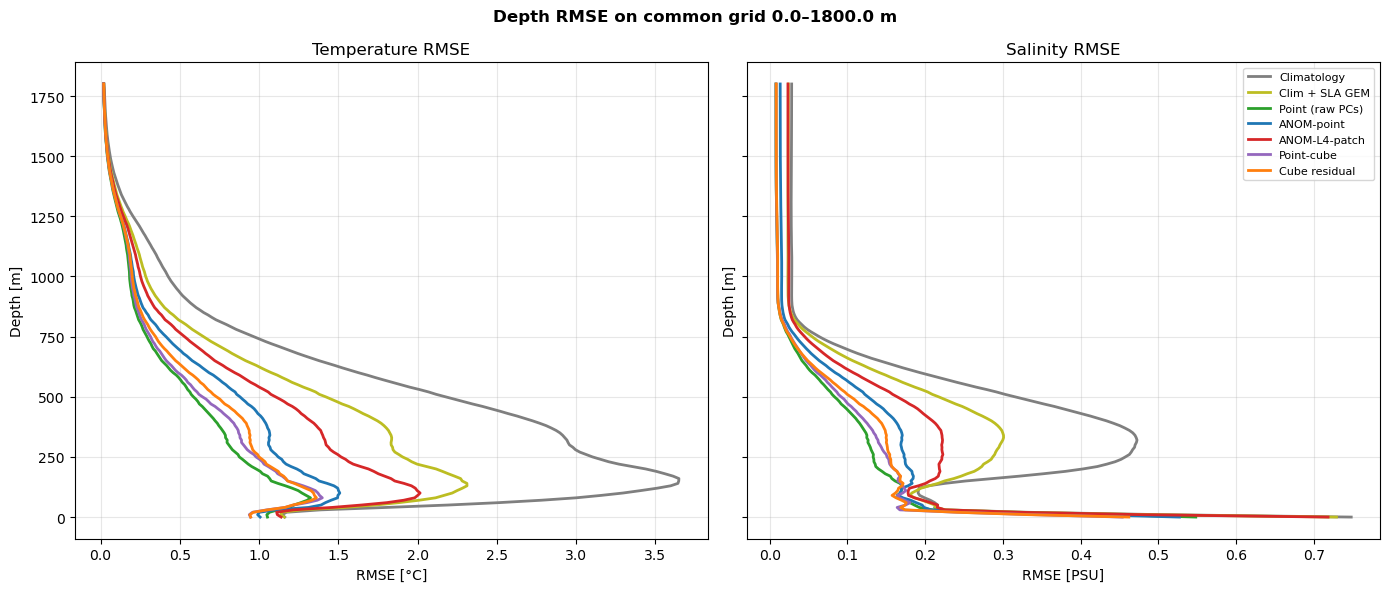

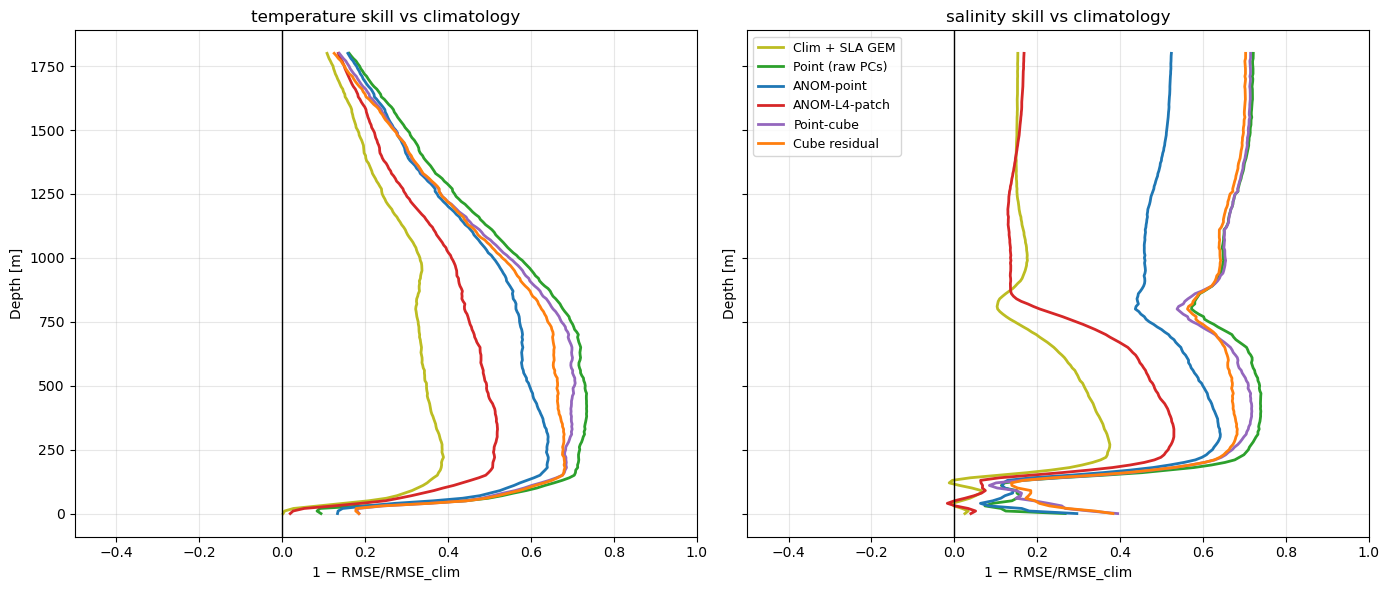

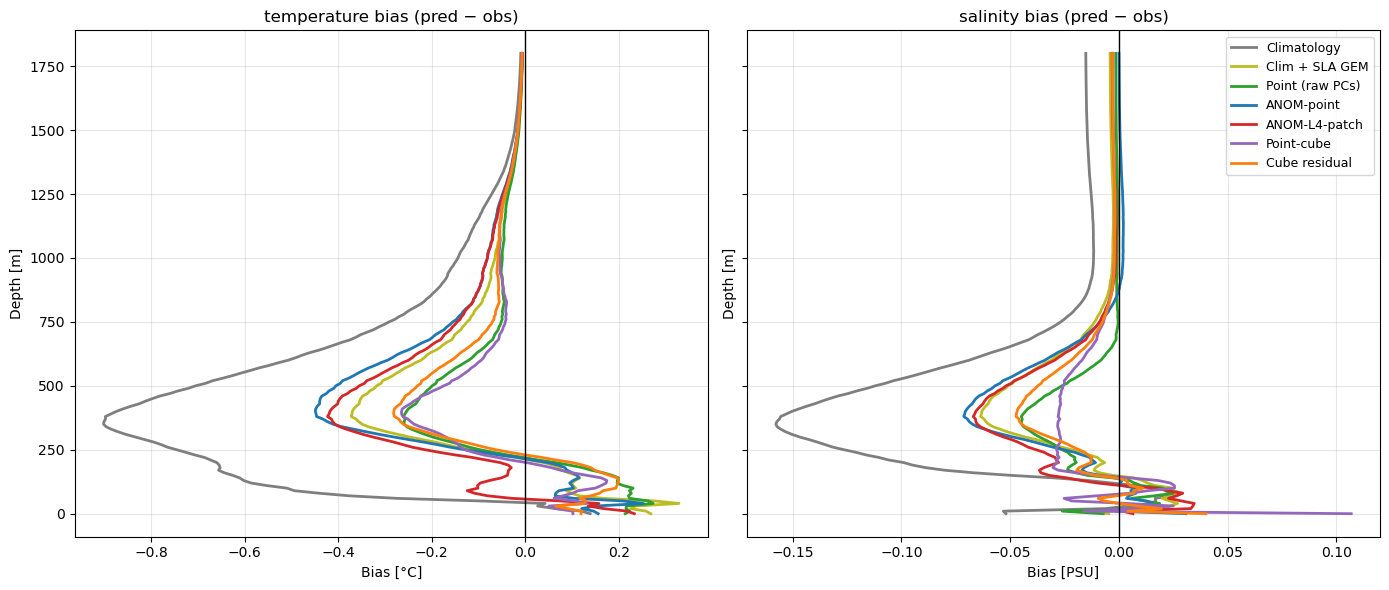

In [18]:
def safe(fn, *args, **kwargs):
    try:
        return fn(*args, **kwargs)
    except Exception:
        print(f"[skipped] {getattr(fn, '__name__', fn)}:")
        traceback.print_exc(limit=2)


safe(plot_depth_rmse_overlay, rows, colors=ROW_COLORS, out_path=OUT_DIR / "scratch_depth_rmse.png")
safe(nb_anom.plot_skill_by_depth, rows)
safe(nb_anom.plot_bias_by_depth, rows)

## Section 11 — Scatter + residual distributions

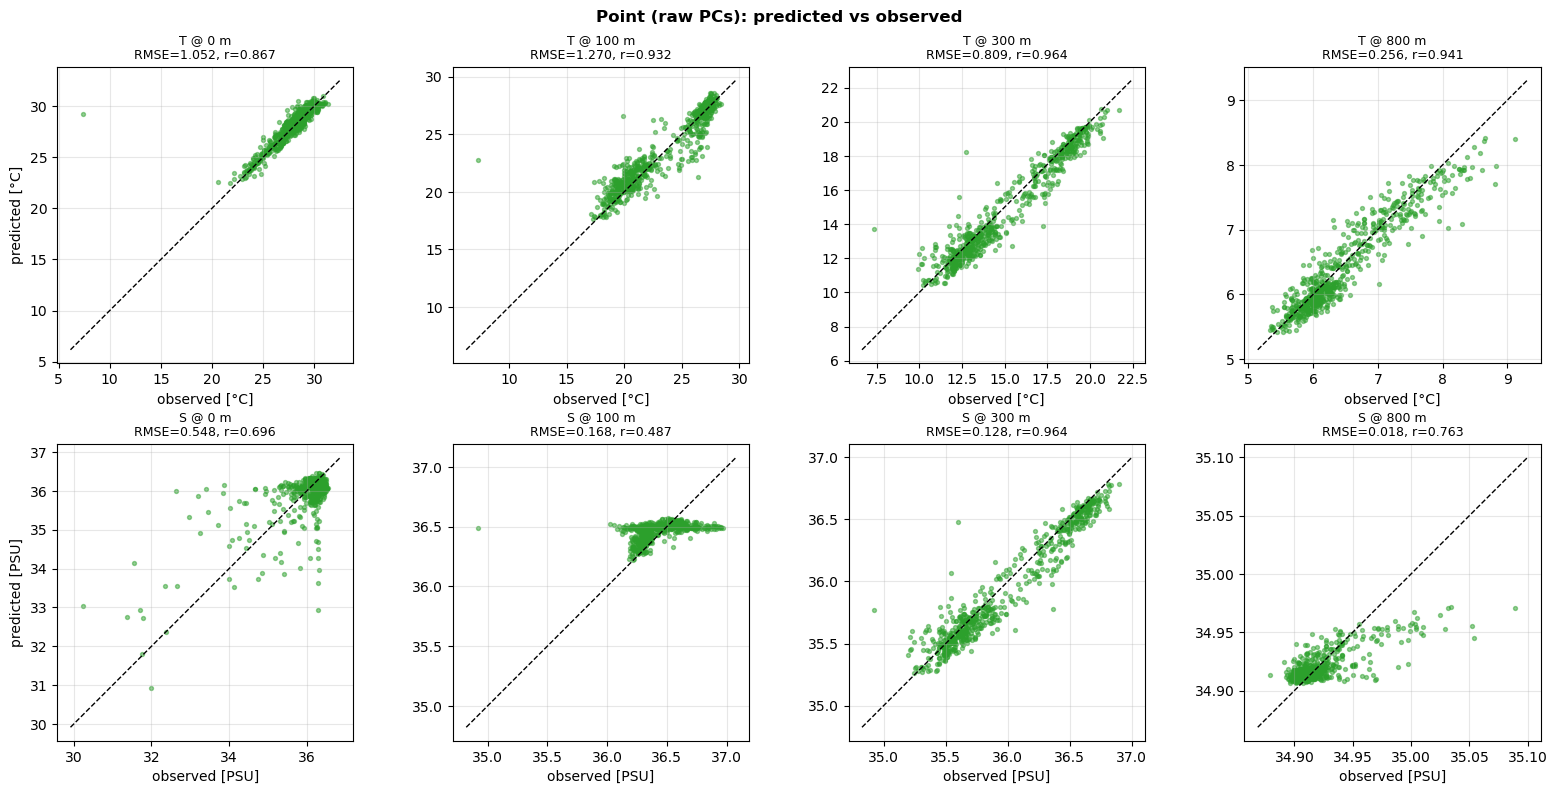

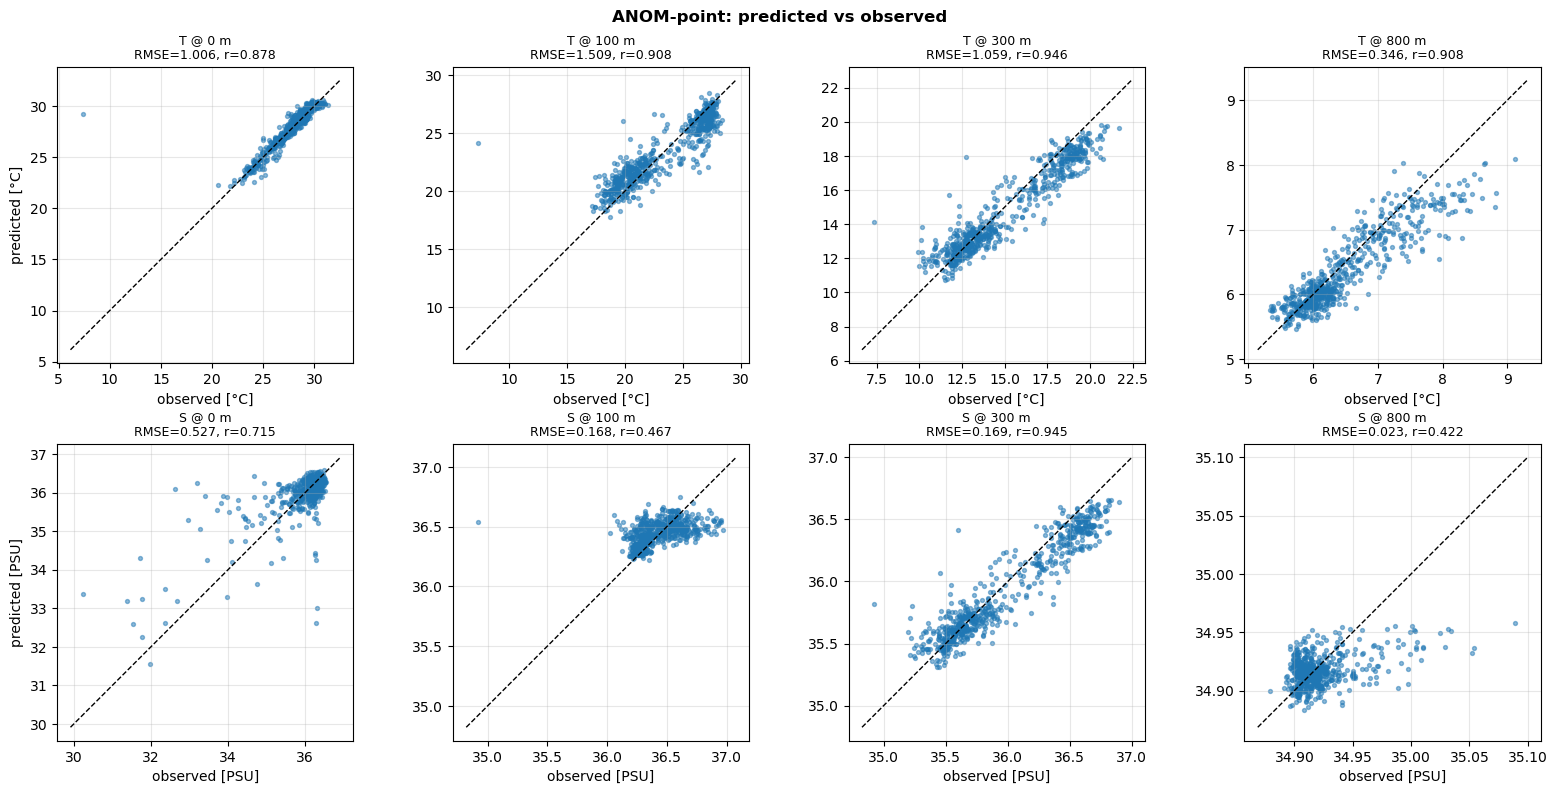

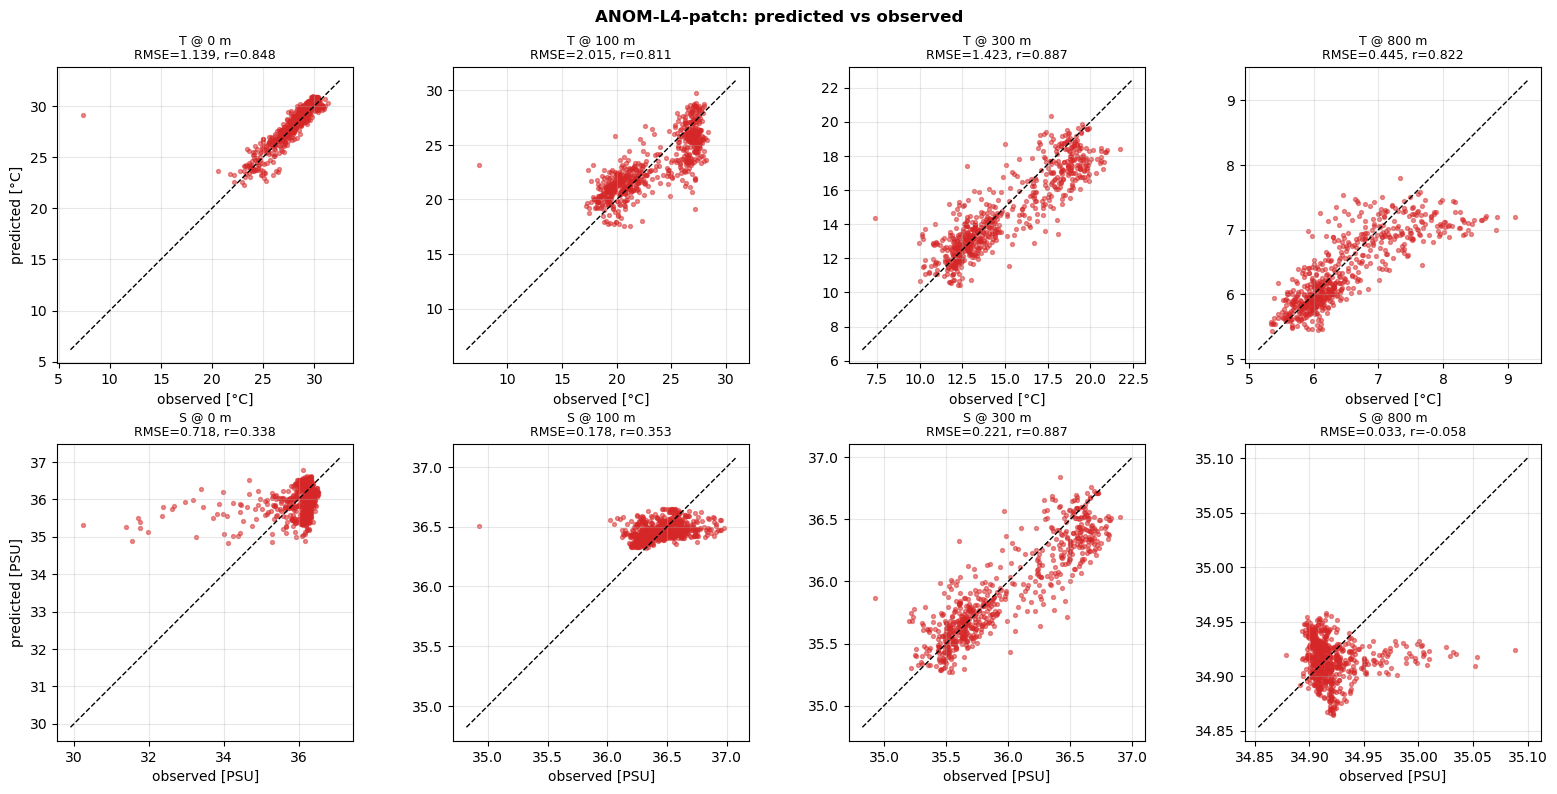

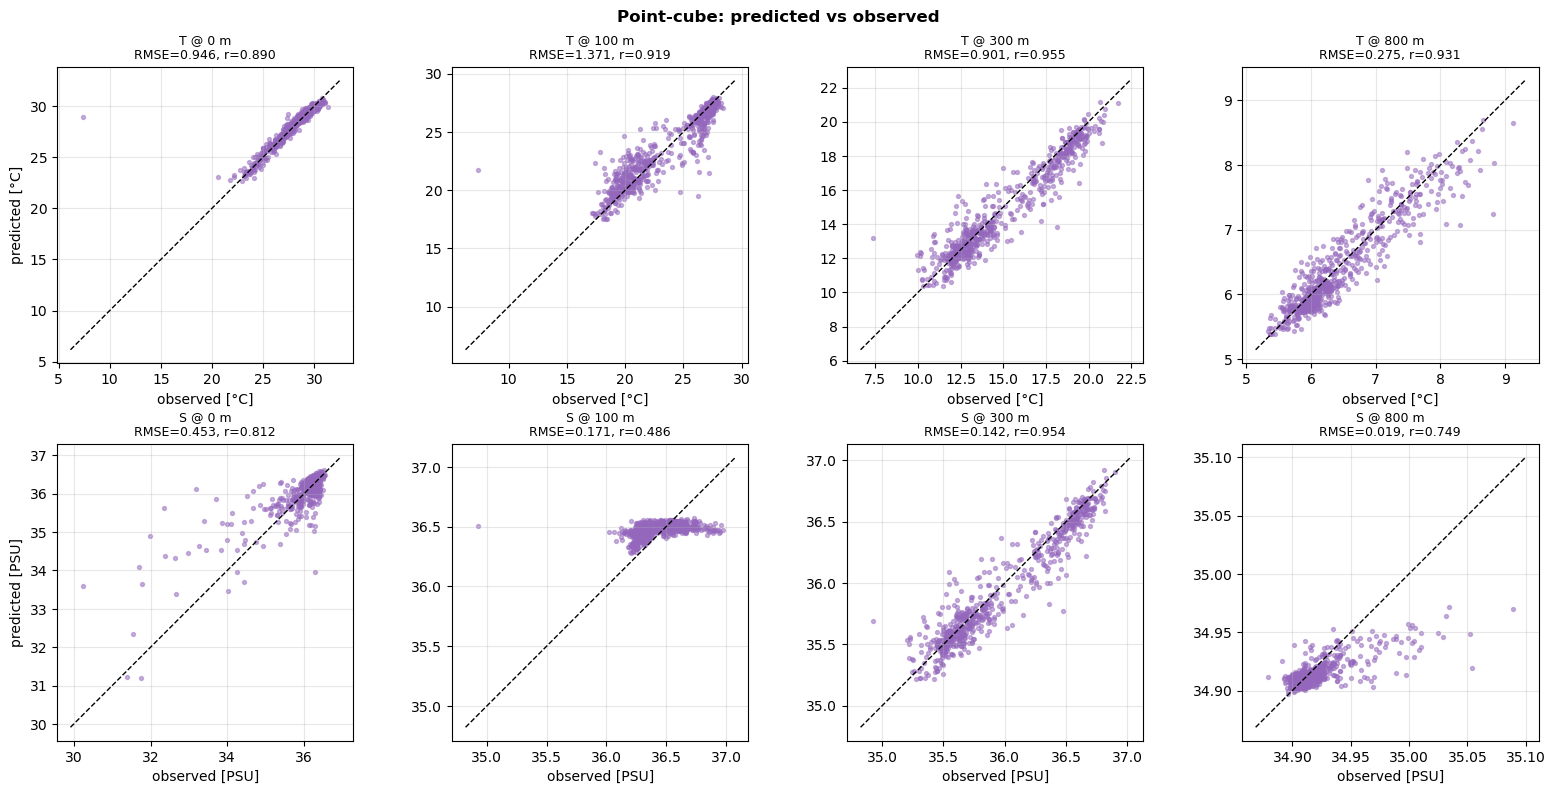

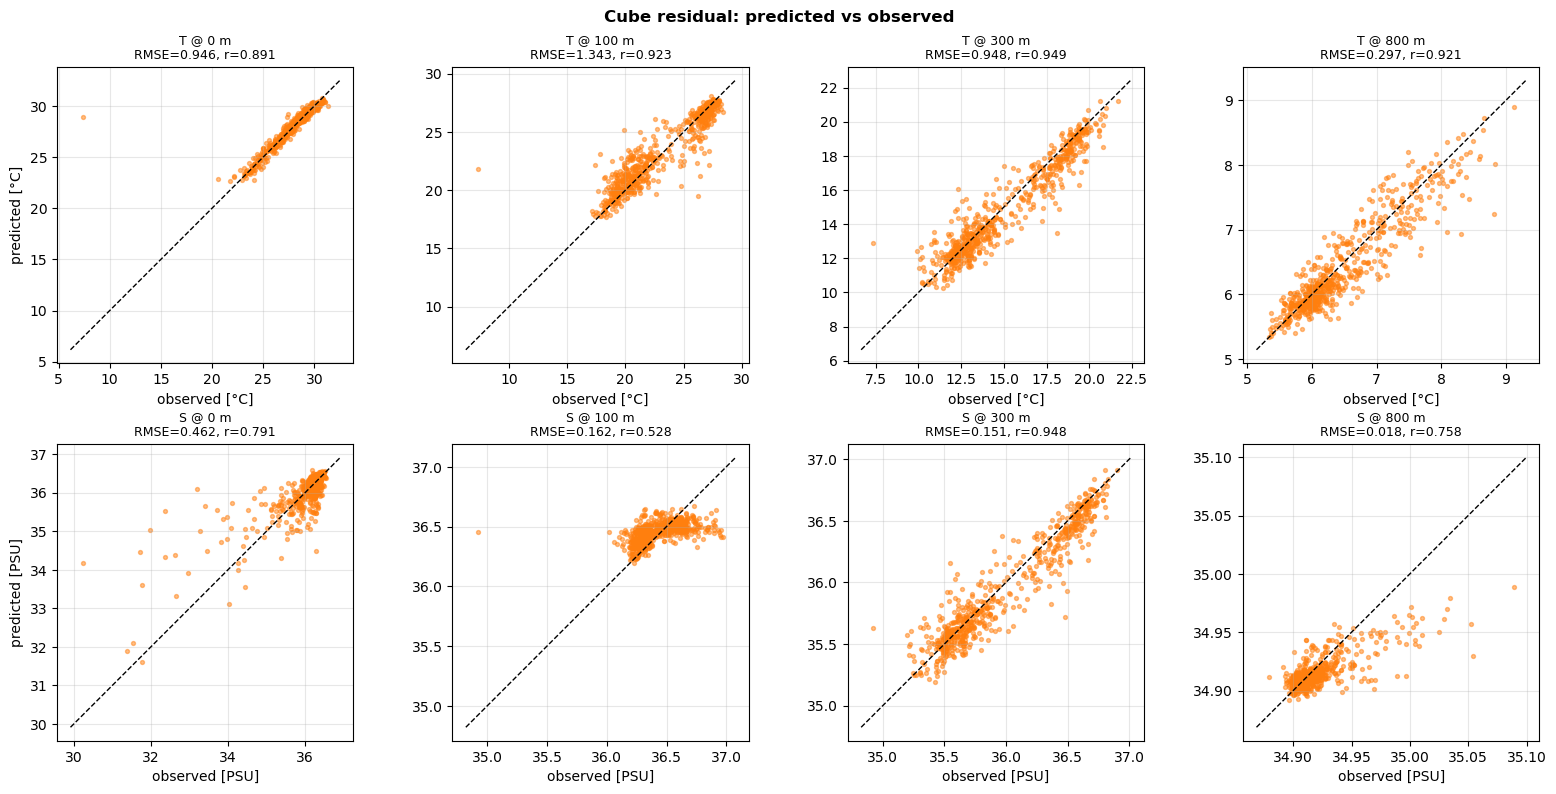

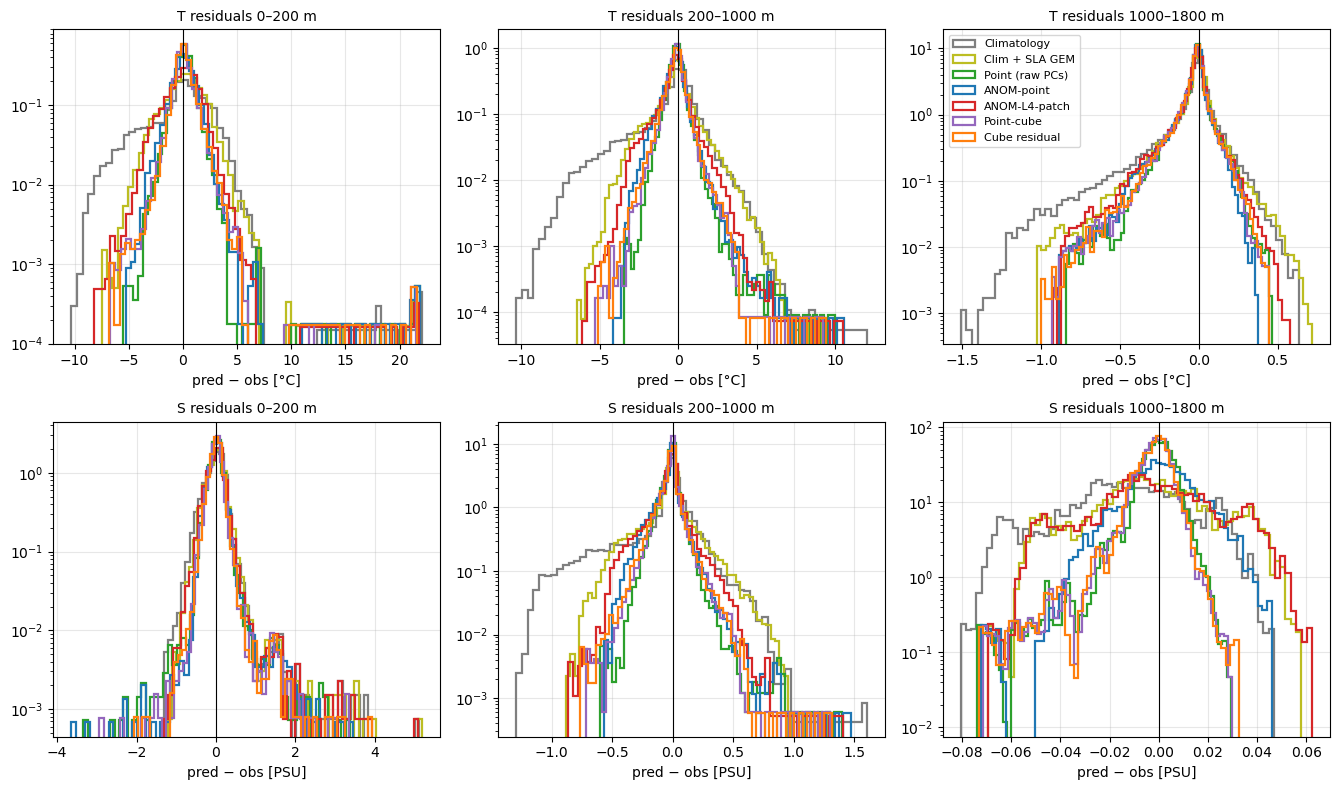

In [19]:
for r in MODEL_ROWS:
    safe(nb_anom.plot_scatter_depths, r, depths=(0, 100, 300, 800))
safe(nb_anom.plot_residual_hist, rows)

## Section 12 — Example profiles (best / median / worst)

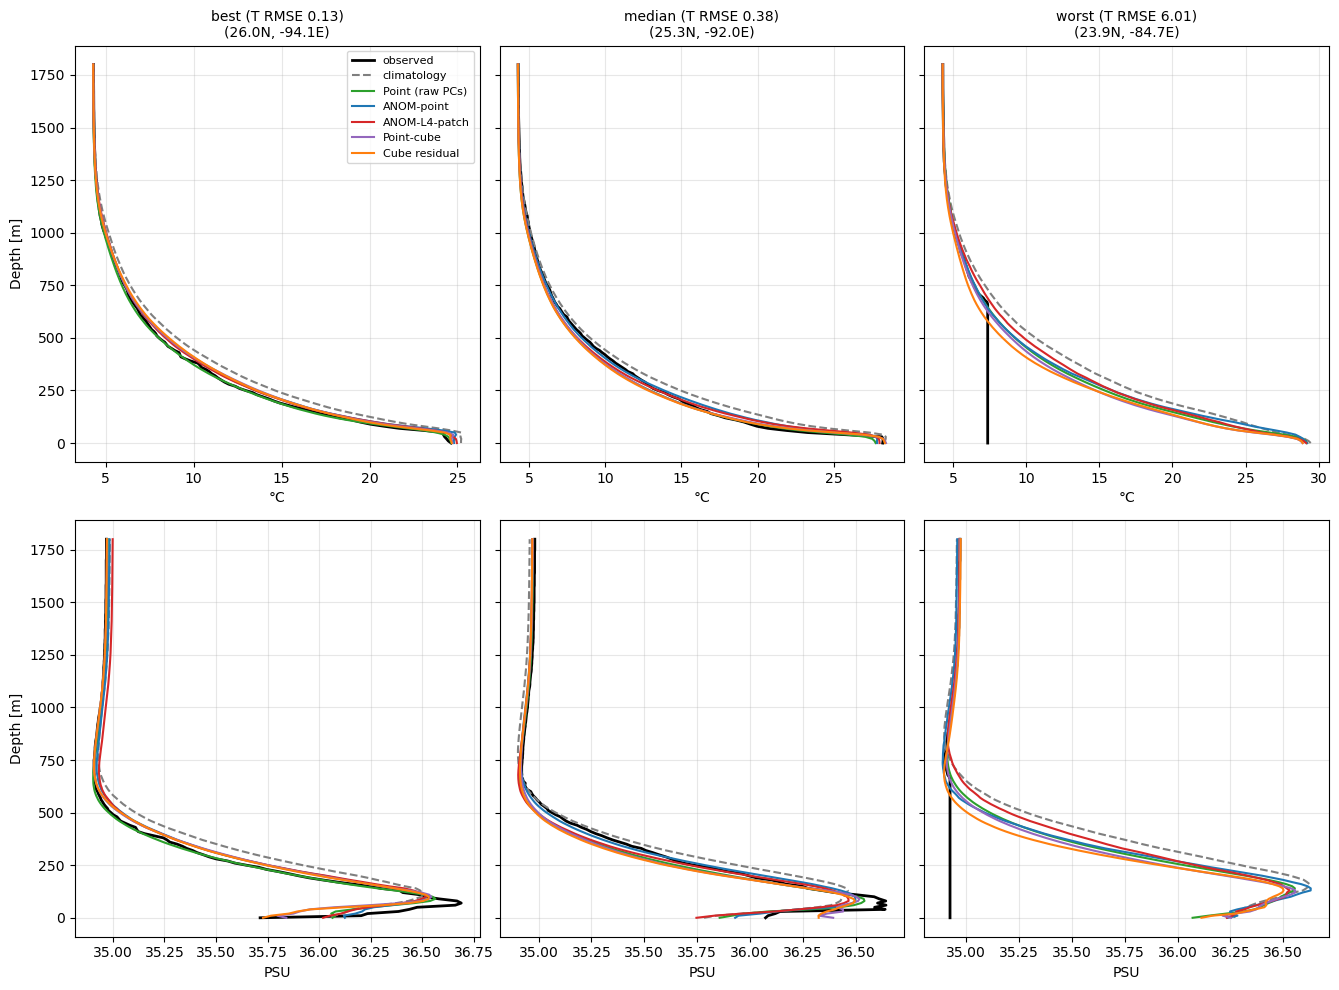

In [20]:
safe(nb_anom.plot_example_profiles, rows)

## Section 13 — Spatial RMSE maps: residual vs its anchor

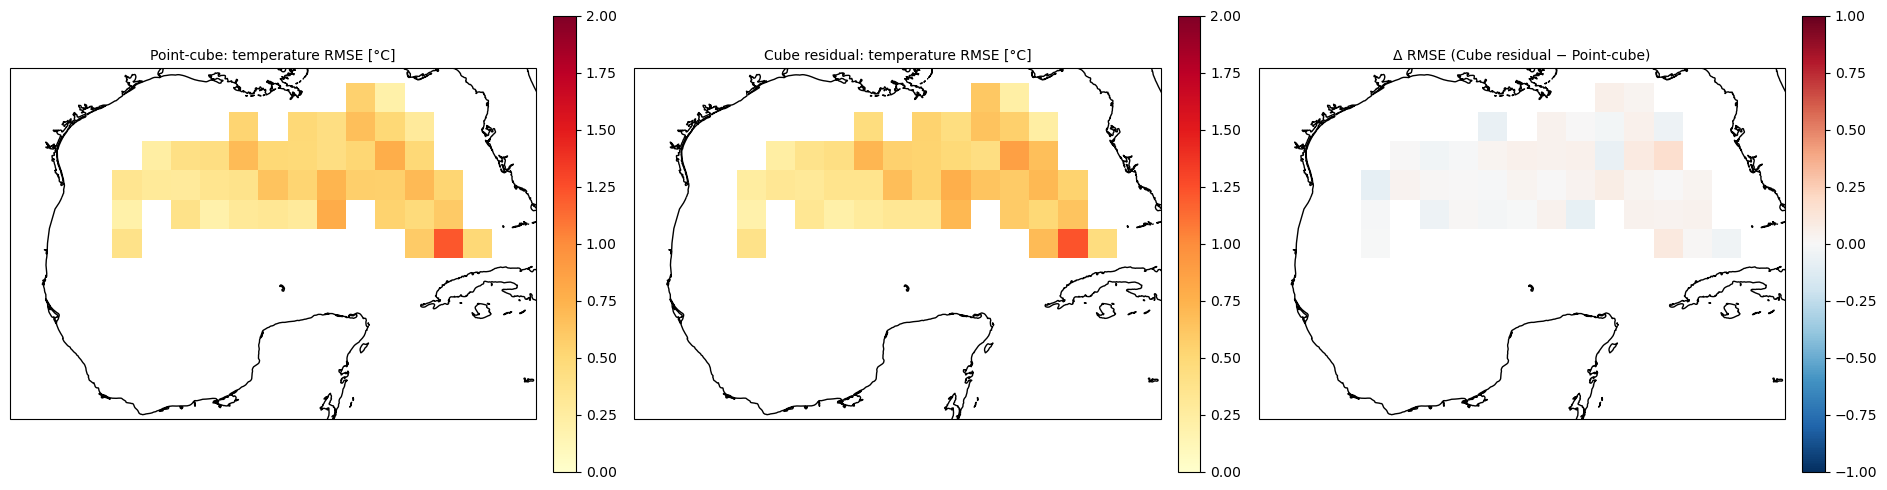

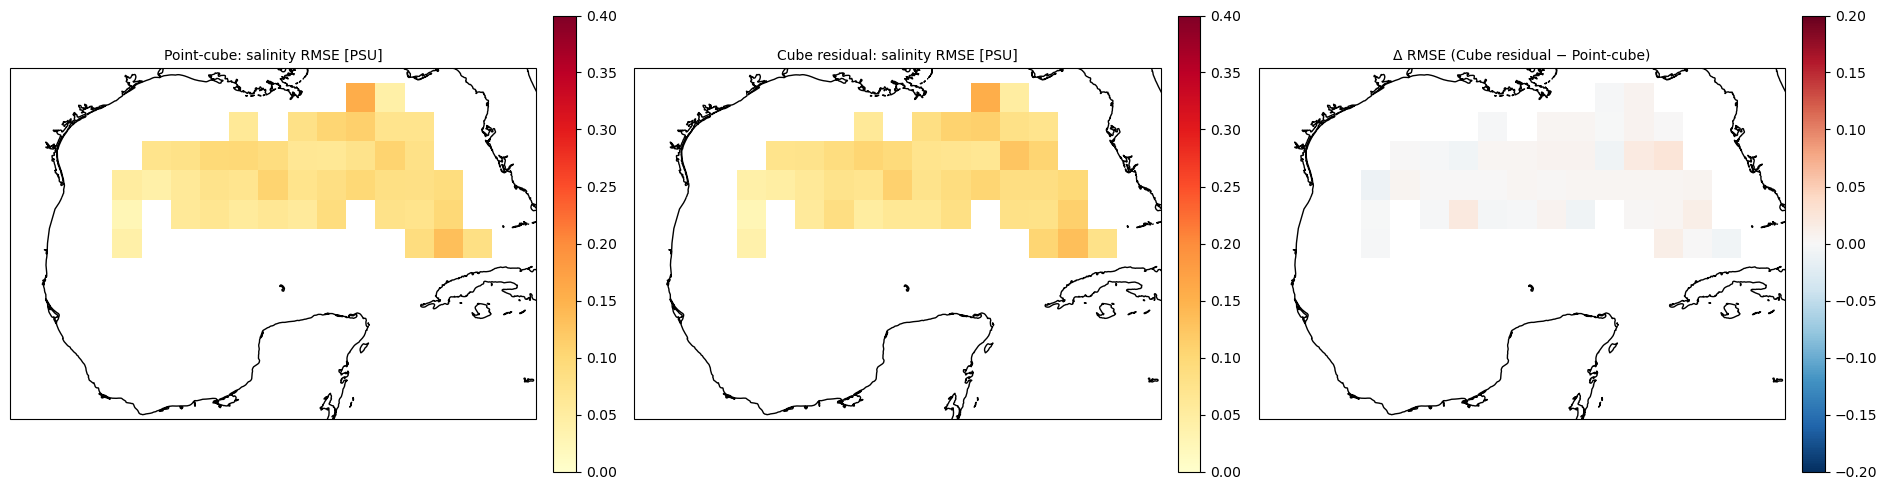

In [21]:
safe(nb_anom.plot_rmse_and_delta_maps, pc, res, variable="temperature", vmax=2.0)
safe(nb_anom.plot_rmse_and_delta_maps, pc, res, variable="salinity", vmax=0.4)

## Section 14 — Export results

In [22]:
nb_anom.export_results(rows, OUT_DIR / "scratch_all_models_results.json", eval_split=EVAL_SPLIT)
print(json.dumps(manifest, indent=2))
print(f"\nDone. Outputs in {OUT_DIR}")

Saved /unity/g2/jmiranda/SubsurfaceFields/Data/ISAS20_ARGO/ISAS20_project/NeSPReSO2_onTemplate/notebooks/scratch_outputs/scratch_all_models_results.json
{
  "golden_point": {
    "checkpoint": "saved/models/NeSPReSO2_ARGO_GoM/scratch_0705_204716_golden_point/model_best.pth",
    "cache_path": "../data/cache/train_ready_3adcff404b0b.pkl",
    "trained_at": "0705_204716",
    "wall_s": 610,
    "best_epoch": 313
  },
  "anom_point": {
    "checkpoint": "saved/models/NeSPReSO2_ARGO_GoM_anom/scratch_0705_204716_anom_point/model_best.pth",
    "cache_path": "../data/cache/train_ready_945ab8874c00.pkl",
    "trained_at": "0705_204716",
    "wall_s": 2367,
    "best_epoch": 3067
  },
  "anom_patch_l4": {
    "checkpoint": "saved/models/NeSPReSO2_ARGO_GoM_patch_l4_anom/scratch_0705_204716_anom_patch_l4/model_best.pth",
    "cache_path": "../data/cache/train_ready_0085aed3c9b8.pkl",
    "trained_at": "0705_204716",
    "wall_s": 1503,
    "best_epoch": 1048
  },
  "point_cube": {
    "checkpoin